# TP3 — Examen Final: Los supermercados de Don Francisco

**Probabilidad y Estadística para la Inteligencia Artificial**  
**Docente:** Camilo Argoty

Don Francisco cuenta hoy con 5 supermercados: *Santa Ana*, *La Floresta*, *Los Cedros*, *Palermo* y *Córdoba*. Matías debe responder las inquietudes del comerciante:

- **Pregunta A:** ¿Cómo se comporta la afluencia de clientes **mes a mes** en *Santa Ana*?
- **Pregunta B:** ¿La afluencia es la **misma en todas las tiendas** o hay alguna que necesita más atención por recibir menos clientes?

El enunciado pide además cuatro tareas cuantitativas:

1. Simular clientes diarios (2023–2025) con **Poisson**($\lambda_t$), donde $\lambda_t$ suma efecto anual, mensual, diario y por tienda.
2. Calcular **intervalos de confianza empíricos** mensuales de *Santa Ana* al 95 % y 99 %.
3. Realizar **ANOVA** (significancia 95 %) para comparar las tiendas.
4. Comparar la tienda de **mayor** y **menor** promedio con una **prueba de hipótesis**, verificando si coinciden con los mayores y menores efectos por tienda.

> **Nota sobre el PDF:** el ítem 1 menciona "Don Francisco y Don Miguel", pero la tabla de efectos corresponde a los 5 supermercados de Don Francisco. Además, en el efecto anual aparece dos veces 2024; se interpreta como **2025: 2000**.

## Configuración inicial

Importamos las librerías que se usan a lo largo del trabajo.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st

Fijamos el estilo de los gráficos y una semilla para que la simulación sea reproducible.

In [2]:
sns.set(style="whitegrid")
np.random.seed(42)

---
## Item 1 — Simulación de clientes con Poisson (2.5 puntos)

Para cada día $t$ y cada tienda, el número de clientes se modela como:

$$N_t \sim \text{Poisson}(\lambda_t)$$

donde el parámetro $\lambda_t$ es la suma de cuatro efectos:

$$\lambda_t = \text{efecto anual} + \text{efecto mensual} + \text{efecto diario} + \text{efecto por tienda}$$

### Paso 1.1 — Efecto anual

Cada año aporta un valor base creciente a la afluencia esperada.

In [3]:
EFECTO_ANUAL = {
    2023: 1000,
    2024: 1500,
    2025: 2000,
}

### Paso 1.2 — Efecto mensual

La estacionalidad mensual (las claves son los números de mes de enero=1 a diciembre=12).

In [4]:
EFECTO_MENSUAL = {
    1: 1000,   # Enero
    2: 1500,   # Febrero
    3: 2000,   # Marzo
    4: 2000,   # Abril
    5: 2500,   # Mayo
    6: 2500,   # Junio
    7: 3000,   # Julio
    8: 2500,   # Agosto
    9: 2500,   # Septiembre
    10: 2000,  # Octubre
    11: 1500,  # Noviembre
    12: 1000,  # Diciembre
}

### Paso 1.3 — Efecto diario

El día de la semana según la convención de pandas (`weekday`): lunes=0, …, domingo=6.

In [5]:
EFECTO_DIARIO = {
    0: 2000,  # Lunes
    1: 3000,  # Martes
    2: 3500,  # Miércoles
    3: 3000,  # Jueves
    4: 2000,  # Viernes
    5: 1000,  # Sábado
    6: 1000,  # Domingo
}

### Paso 1.4 — Efecto por tienda

El aporte fijo de cada uno de los 5 supermercados de Don Francisco.

In [6]:
EFECTO_TIENDA = {
    "Santa Ana": 5000,
    "La Floresta": 2000,
    "Los Cedros": 3000,
    "Palermo": 1000,
    "Córdoba": 3000,
}

### Paso 1.5 — Función que calcula $\lambda_t$

Dado un conjunto de fechas y una tienda, sumamos los cuatro efectos. Usamos `.map()` para traducir cada fecha a su efecto correspondiente.

In [7]:
def calcular_lambda(fechas: pd.DatetimeIndex, tienda: str) -> np.ndarray:
    """Vector de lambdas (uno por fecha) para una tienda dada."""
    return (
        fechas.year.map(EFECTO_ANUAL)
        + fechas.month.map(EFECTO_MENSUAL)
        + fechas.weekday.map(EFECTO_DIARIO)
        + EFECTO_TIENDA[tienda]
    ).to_numpy()

### Paso 1.6 — Función que simula una tienda

Generamos todas las fechas del rango 2023–2025, calculamos sus $\lambda_t$ y muestreamos un valor Poisson por día.

In [8]:
def simular_tienda(tienda: str, anios=(2023, 2024, 2025)) -> pd.DataFrame:
    """Simula los conteos diarios Poisson de una tienda en los años indicados."""
    fechas = pd.date_range(f"{min(anios)}-01-01", f"{max(anios)}-12-31", freq="D")
    lambdas = calcular_lambda(fechas, tienda)
    clientes = np.random.poisson(lam=lambdas)
    df = pd.DataFrame({
        "fecha": fechas,
        "anio": fechas.year,
        "mes": fechas.month,
        "tienda": tienda,
        "clientes": clientes,
    })
    return df[df["anio"].isin(anios)].reset_index(drop=True)

### Paso 1.7 — Simular las 5 tiendas

Guardamos cada simulación en un diccionario para acceder fácilmente por nombre.

In [9]:
simulaciones = {tienda: simular_tienda(tienda) for tienda in EFECTO_TIENDA}

### Paso 1.8 — Consolidar en un único DataFrame

Concatenamos todas las tiendas en una sola tabla para los análisis posteriores.

In [10]:
datos = pd.concat(simulaciones.values(), ignore_index=True)
datos.head()

,fecha,anio,mes,tienda,clientes
0,2023-01-01,2023,1,Santa Ana,7968
1,2023-01-02,2023,1,Santa Ana,9066
2,2023-01-03,2023,1,Santa Ana,9885
3,2023-01-04,2023,1,Santa Ana,10288
4,2023-01-05,2023,1,Santa Ana,10029


### Paso 1.9 — Verificación rápida

Comprobamos la cantidad de registros por tienda (3 años de días) y el promedio de clientes.

In [11]:
resumen = datos.groupby("tienda")["clientes"].agg(["count", "mean", "std"])
resumen

,count,mean,std
tienda,,,
Córdoba,1096,8723.688869,1186.768882
La Floresta,1096,7715.389599,1181.314453
Los Cedros,1096,8717.857664,1184.117276
Palermo,1096,6715.697993,1186.431657
Santa Ana,1096,10713.349453,1187.382621


### Paso 1.10 — Visualización de la afluencia de *Santa Ana*

Graficamos la serie temporal de clientes para apreciar la estacionalidad.

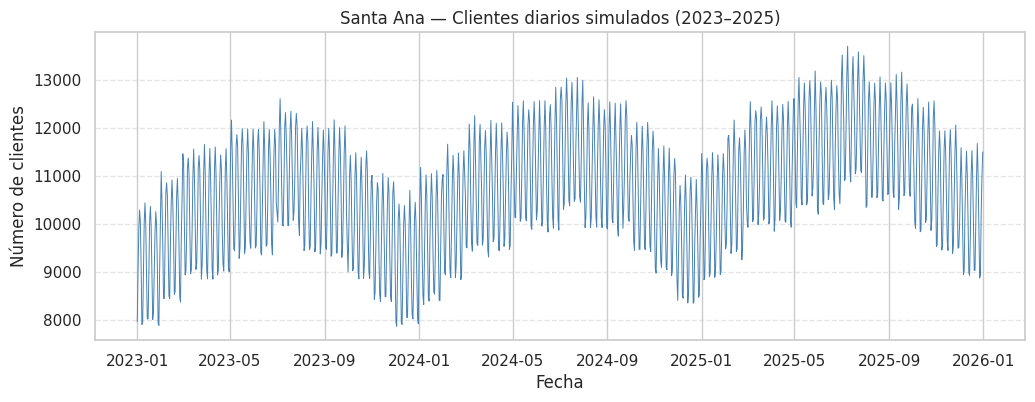

In [12]:
santa_ana = simulaciones["Santa Ana"]

plt.figure(figsize=(12, 4))
plt.plot(santa_ana["fecha"], santa_ana["clientes"], color="steelblue", lw=0.7)
plt.title("Santa Ana — Clientes diarios simulados (2023–2025)")
plt.xlabel("Fecha")
plt.ylabel("Número de clientes")
plt.grid(axis="y", ls="--", alpha=0.5)
plt.show()

---
## Item 2 — Intervalos de confianza empíricos para *Santa Ana* (2.5 puntos)

Don Francisco quiere entender la afluencia **mes a mes** de *Santa Ana*. Según la notebook *7. Intervalos de confianza* (sección bootstrap), un **intervalo de confianza empírico** para la media se construye así:

1. Tomar los conteos diarios del mes.
2. Generar remuestras bootstrap (con reemplazo) y calcular la media en cada una.
3. Tomar los percentiles $P_{\alpha/2}$ y $P_{1-\alpha/2}$ de esas medias bootstrap.

Para cada mes usamos todos los días de ese mes en 2023, 2024 y 2025.

- 95 %: percentiles 2.5 y 97.5 de las medias bootstrap
- 99 %: percentiles 0.5 y 99.5 de las medias bootstrap

### Paso 2.1 — Aislar los datos de *Santa Ana*

In [13]:
santa_ana = simulaciones["Santa Ana"]
santa_ana.head()

,fecha,anio,mes,tienda,clientes
0,2023-01-01,2023,1,Santa Ana,7968
1,2023-01-02,2023,1,Santa Ana,9066
2,2023-01-03,2023,1,Santa Ana,9885
3,2023-01-04,2023,1,Santa Ana,10288
4,2023-01-05,2023,1,Santa Ana,10029


### Paso 2.2 — Función de intervalo bootstrap para la media

Replicamos el procedimiento de la notebook de intervalos de confianza: remuestreamos con reemplazo y tomamos percentiles de las medias obtenidas.

In [14]:
def intervalo_bootstrap(datos_mes: np.ndarray, confianza: float, n_bootstrap: int = 10000) -> tuple:
    """IC empírico bootstrap para la media diaria del mes."""
    n = len(datos_mes)
    alpha = 1 - confianza
    medias_bootstrap = np.array([
        np.mean(np.random.choice(datos_mes, size=n, replace=True))
        for _ in range(n_bootstrap)
    ])
    inferior, superior = np.percentile(medias_bootstrap, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return inferior, superior

### Paso 2.3 — Nombres de los meses

Para presentar la tabla de forma legible.

In [15]:
NOMBRE_MES = {
    1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril",
    5: "Mayo", 6: "Junio", 7: "Julio", 8: "Agosto",
    9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre",
}

### Paso 2.4 — Calcular los intervalos mes a mes

Recorremos los 12 meses, agrupando todos los días de ese mes (de los 3 años) y calculando ambos intervalos.

In [16]:
filas = []
for mes in range(1, 13):
    clientes_mes = santa_ana.loc[santa_ana["mes"] == mes, "clientes"].to_numpy()
    ic95_inf, ic95_sup = intervalo_bootstrap(clientes_mes, 0.95)
    ic99_inf, ic99_sup = intervalo_bootstrap(clientes_mes, 0.99)
    filas.append({
        "mes": NOMBRE_MES[mes],
        "media": clientes_mes.mean(),
        "IC95_inf": ic95_inf,
        "IC95_sup": ic95_sup,
        "IC99_inf": ic99_inf,
        "IC99_sup": ic99_sup,
    })

### Paso 2.5 — Tabla de resultados

In [17]:
tabla_ic = pd.DataFrame(filas).round(1)
tabla_ic

,mes,media,IC95_inf,IC95_sup,IC99_inf,IC99_sup
0,Enero,9730.0,9518.5,9941.5,9460.3,10001.5
1,Febrero,10219.5,9998.5,10431.7,9942.7,10498.4
2,Marzo,10694.8,10493.4,10896.6,10430.8,10955.9
3,Abril,10736.5,10526.3,10944.9,10458.3,11016.9
4,Mayo,11245.9,11035.7,11444.9,10980.4,11512.1
5,Junio,11177.4,10966.2,11389.9,10903.9,11454.8
6,Julio,11711.2,11503.0,11921.4,11423.1,11986.7
7,Agosto,11216.7,11016.1,11414.2,10958.5,11482.5
8,Septiembre,11178.6,10968.8,11388.1,10902.6,11454.2
9,Octubre,10744.4,10531.1,10953.7,10471.8,11027.4


### Paso 2.6 — Visualización de los intervalos

Graficamos la media mensual con las bandas del 95 % y del 99 % (esta última siempre más ancha porque exige mayor confianza).

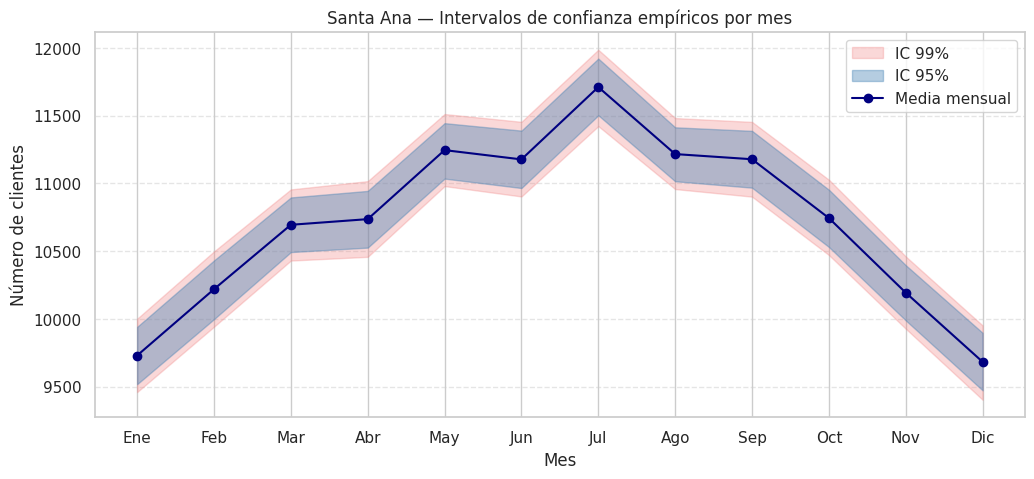

In [18]:
meses = np.arange(1, 13)

plt.figure(figsize=(12, 5))
plt.fill_between(meses, tabla_ic["IC99_inf"], tabla_ic["IC99_sup"],
                 color="lightcoral", alpha=0.3, label="IC 99%")
plt.fill_between(meses, tabla_ic["IC95_inf"], tabla_ic["IC95_sup"],
                 color="steelblue", alpha=0.4, label="IC 95%")
plt.plot(meses, tabla_ic["media"], "o-", color="navy", label="Media mensual")
plt.xticks(meses, [NOMBRE_MES[m][:3] for m in meses])
plt.title("Santa Ana — Intervalos de confianza empíricos por mes")
plt.xlabel("Mes")
plt.ylabel("Número de clientes")
plt.legend()
plt.grid(axis="y", ls="--", alpha=0.5)
plt.show()

**Lectura del resultado.** Los meses de invierno (especialmente julio) presentan la media diaria más alta, coherente con el mayor efecto mensual. El intervalo del 99 % es más ancho que el del 95 % en todos los meses, como corresponde a un mayor nivel de confianza.

---
## Item 3 — ANOVA entre tiendas (2.5 puntos)

Queremos decidir si la afluencia esperada es **igual en todas las tiendas** o si al menos una difiere. Usamos un **ANOVA de un factor** con significancia del 95 % ($\alpha = 0{,}05$).

- $H_0$: $\mu_{\text{Santa Ana}} = \mu_{\text{La Floresta}} = \mu_{\text{Los Cedros}} = \mu_{\text{Palermo}} = \mu_{\text{Córdoba}}$
- $H_1$: al menos una media difiere de las demás

### Paso 3.1 — Preparar los grupos

Cada grupo es el vector de conteos diarios de una tienda.

In [19]:
grupos = {tienda: simulaciones[tienda]["clientes"].to_numpy() for tienda in EFECTO_TIENDA}
for tienda, valores in grupos.items():
    print(f"{tienda:<12} n={len(valores)}  media={valores.mean():.1f}")

Santa Ana    n=1096  media=10713.3
La Floresta  n=1096  media=7715.4
Los Cedros   n=1096  media=8717.9
Palermo      n=1096  media=6715.7
Córdoba      n=1096  media=8723.7


### Paso 3.2 — Calcular los componentes del ANOVA a mano

Para dejar explícito el procedimiento calculamos las sumas de cuadrados entre y dentro de los grupos.

$$SS_{\text{entre}} = \sum_{j} n_j (\bar{x}_j - \bar{x})^2, \qquad SS_{\text{dentro}} = \sum_{j}\sum_{i}(x_{ij}-\bar{x}_j)^2$$

In [20]:
lista_grupos = list(grupos.values())
k = len(lista_grupos)
N = sum(len(g) for g in lista_grupos)
media_global = np.concatenate(lista_grupos).mean()

ss_entre = sum(len(g) * (g.mean() - media_global) ** 2 for g in lista_grupos)
ss_dentro = sum(((g - g.mean()) ** 2).sum() for g in lista_grupos)

print(f"k (grupos)      = {k}")
print(f"N (total)       = {N}")
print(f"media global     = {media_global:.2f}")
print(f"SS entre grupos  = {ss_entre:.2f}")
print(f"SS dentro grupos = {ss_dentro:.2f}")

k (grupos)      = 5
N (total)       = 5480
media global     = 8517.20
SS entre grupos  = 9638534136.40
SS dentro grupos = 7690793279.54


### Paso 3.3 — Grados de libertad y medias de cuadrados

$$df_{\text{entre}} = k-1, \qquad df_{\text{dentro}} = N-k$$
$$MS = \frac{SS}{df}, \qquad F = \frac{MS_{\text{entre}}}{MS_{\text{dentro}}}$$

In [21]:
df_entre = k - 1
df_dentro = N - k
ms_entre = ss_entre / df_entre
ms_dentro = ss_dentro / df_dentro
F_manual = ms_entre / ms_dentro

print(f"df entre  = {df_entre}")
print(f"df dentro = {df_dentro}")
print(f"MS entre  = {ms_entre:.2f}")
print(f"MS dentro = {ms_dentro:.2f}")
print(f"F         = {F_manual:.4f}")

df entre  = 4
df dentro = 5475
MS entre  = 2409633534.10
MS dentro = 1404711.10
F         = 1715.3944


### Paso 3.4 — p-valor y verificación con `scipy`

Calculamos el p-valor a partir de la distribución $F$ y lo contrastamos con `st.f_oneway`.

In [22]:
p_manual = st.f.sf(F_manual, df_entre, df_dentro)
F_scipy, p_scipy = st.f_oneway(*lista_grupos)

print(f"Cálculo manual : F = {F_manual:.4f}, p = {p_manual:.3e}")
print(f"scipy.f_oneway : F = {F_scipy:.4f}, p = {p_scipy:.3e}")

Cálculo manual : F = 1715.3944, p = 0.000e+00
scipy.f_oneway : F = 1715.3944, p = 0.000e+00


### Paso 3.5 — Decisión

In [23]:
alpha = 0.05
if p_scipy < alpha:
    print(f"p = {p_scipy:.3e} < {alpha}: rechazamos H0.")
    print("Al menos una tienda tiene una afluencia media distinta.")
else:
    print(f"p = {p_scipy:.3e} >= {alpha}: no se rechaza H0.")
    print("No hay evidencia de diferencias entre tiendas.")

p = 0.000e+00 < 0.05: rechazamos H0.
Al menos una tienda tiene una afluencia media distinta.


### Paso 3.6 — Visualización comparativa

Un boxplot permite ver las diferencias de nivel entre tiendas.

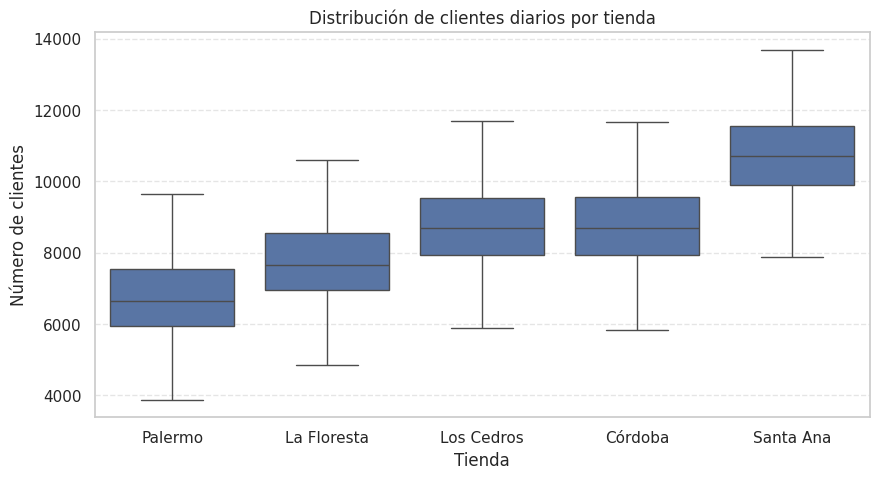

In [24]:
orden = sorted(EFECTO_TIENDA, key=lambda t: grupos[t].mean())

plt.figure(figsize=(10, 5))
sns.boxplot(data=datos, x="tienda", y="clientes", order=orden)
plt.title("Distribución de clientes diarios por tienda")
plt.xlabel("Tienda")
plt.ylabel("Número de clientes")
plt.grid(axis="y", ls="--", alpha=0.5)
plt.show()

---
## Item 4 — Tienda con mayor vs. menor promedio (2.5 puntos)

Identificamos la tienda con **mayor** y con **menor** promedio de clientes y probamos si la diferencia de medias es distinta de cero.

- $H_0$: $\mu_{\text{mayor}} - \mu_{\text{menor}} = 0$
- $H_1$: $\mu_{\text{mayor}} - \mu_{\text{menor}} \neq 0$

Significancia del 95 % ($\alpha = 0{,}05$).

### Paso 4.1 — Calcular el promedio de cada tienda

In [25]:
promedios = datos.groupby("tienda")["clientes"].mean().sort_values()
promedios

tienda
Palermo         6715.697993
La Floresta     7715.389599
Los Cedros      8717.857664
Córdoba         8723.688869
Santa Ana      10713.349453
Name: clientes, dtype: float64

### Paso 4.2 — Identificar las tiendas extremas

In [26]:
tienda_mayor = promedios.idxmax()
tienda_menor = promedios.idxmin()

print(f"Mayor promedio: {tienda_mayor} ({promedios[tienda_mayor]:.1f} clientes/día)")
print(f"Menor promedio: {tienda_menor} ({promedios[tienda_menor]:.1f} clientes/día)")

Mayor promedio: Santa Ana (10713.3 clientes/día)
Menor promedio: Palermo (6715.7 clientes/día)


### Paso 4.3 — Extraer las muestras de ambas tiendas

In [27]:
muestra_mayor = grupos[tienda_mayor]
muestra_menor = grupos[tienda_menor]

print(f"{tienda_mayor}: n={len(muestra_mayor)}, media={muestra_mayor.mean():.1f}, std={muestra_mayor.std(ddof=1):.1f}")
print(f"{tienda_menor}: n={len(muestra_menor)}, media={muestra_menor.mean():.1f}, std={muestra_menor.std(ddof=1):.1f}")

Santa Ana: n=1096, media=10713.3, std=1187.4
Palermo: n=1096, media=6715.7, std=1186.4


### Paso 4.4 — Prueba t para diferencia de medias

Usamos un test t de dos muestras independientes. Como las varianzas pueden diferir, aplicamos la corrección de Welch (`equal_var=False`).

In [28]:
t_stat, p_valor = st.ttest_ind(muestra_mayor, muestra_menor, equal_var=False)

print(f"Diferencia de medias = {muestra_mayor.mean() - muestra_menor.mean():.1f}")
print(f"Estadístico t        = {t_stat:.4f}")
print(f"p-valor              = {p_valor:.3e}")

Diferencia de medias = 3997.7
Estadístico t        = 78.8458
p-valor              = 0.000e+00


### Paso 4.5 — Decisión

In [29]:
alpha = 0.05
if p_valor < alpha:
    print(f"p = {p_valor:.3e} < {alpha}: rechazamos H0.")
    print(f"La diferencia entre {tienda_mayor} y {tienda_menor} es significativa (distinta de cero).")
else:
    print(f"p = {p_valor:.3e} >= {alpha}: no se rechaza H0.")
    print("No hay evidencia de diferencia entre ambas tiendas.")

p = 0.000e+00 < 0.05: rechazamos H0.
La diferencia entre Santa Ana y Palermo es significativa (distinta de cero).


### Paso 4.6 — Verificar contra los efectos por tienda

Comprobamos si las tiendas identificadas coinciden con las de mayor y menor **efecto** de diseño.

In [30]:
tienda_efecto_mayor = max(EFECTO_TIENDA, key=EFECTO_TIENDA.get)
tienda_efecto_menor = min(EFECTO_TIENDA, key=EFECTO_TIENDA.get)

print(f"Efecto más alto:  {tienda_efecto_mayor} ({EFECTO_TIENDA[tienda_efecto_mayor]})")
print(f"Efecto más bajo:  {tienda_efecto_menor} ({EFECTO_TIENDA[tienda_efecto_menor]})")
print()
print(f"¿Mayor promedio coincide con mayor efecto? {tienda_mayor == tienda_efecto_mayor}")
print(f"¿Menor promedio coincide con menor efecto? {tienda_menor == tienda_efecto_menor}")

Efecto más alto:  Santa Ana (5000)
Efecto más bajo:  Palermo (1000)

¿Mayor promedio coincide con mayor efecto? True
¿Menor promedio coincide con menor efecto? True


**Observación.** Aunque $\lambda_t$ combina cuatro efectos, los aportes anual, mensual y diario son idénticos para todas las tiendas en cada fecha. Por lo tanto, las diferencias entre tiendas provienen exclusivamente del efecto por tienda, y la tienda con mayor (menor) efecto debe ser también la de mayor (menor) promedio observado.

---
## Informe (estructura pedida en el examen)

### 1. Planteamiento de los problemas de investigación

- **Pregunta A:** caracterizar la afluencia mensual de clientes en *Santa Ana*.
- **Pregunta B:** determinar si todas las tiendas tienen la misma afluencia esperada o si alguna requiere atención por baja concurrencia.

### 2. Procesamiento realizado a los datos

- Simulación Poisson diaria (2023–2025) con $\lambda_t$ = efecto anual + mensual + diario + por tienda.
- IC empíricos bootstrap de la media diaria de *Santa Ana* por mes (95 % y 99 %).
- ANOVA de un factor entre las 5 tiendas ($\alpha = 0{,}05$), con cálculo manual de $SS$, $MS$ y $F$.
- Test $t$ de Welch entre la tienda de mayor y menor promedio.

### 3. Resultados encontrados

- *Santa Ana* tiene la mayor afluencia media (~10 700 clientes/día); *Palermo* la menor (~6 700).
- Los meses de mayor concurrencia en *Santa Ana* son julio y agosto; los de menor, enero y diciembre.
- ANOVA: $p \approx 0$ → se rechaza la igualdad de medias entre tiendas.
- Test $t$ Santa Ana vs Palermo: $p \approx 0$ → la diferencia es significativa.
- Las tiendas extremas coinciden con los extremos del efecto por tienda (5000 y 1000).

### 4. Análisis y conclusiones

La simulación reproduce la estructura del modelo: la estacionalidad anual/mensual/diaria es común a todas las tiendas, y las diferencias entre locales provienen del efecto por tienda. Por eso *Santa Ana* lidera y *Palermo* queda rezagada.

Don Francisco puede usar los IC mensuales de *Santa Ana* para planificar personal y stock según la época del año. El ANOVA y el test de extremos confirman que **no** todas las tiendas se comportan igual: *Palermo* requiere atención estratégica por ser la de menor afluencia.